### This is an implementation of the XOR classifier using alternating projections

In [79]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import jax.numpy as jnp
import jax.random as random
import tools.optimize as optimize
import tools.projections as projections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import jax
rand_key = random.key(123)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
@jax.jit
def reluActivationVectorized(x, W, z):
    """
    Vectorized ReLU activation projection.
    x is the pre-activation input, W is the identity matrix, z is the target post-activation.
    """
    H = W @ x

    # Solution 1: project onto inactive branch (x <= 0, output = 0)
    x_1 = jnp.clip(H, a_max=0)
    dist_1 = (H - x_1)**2 + z**2

    # Solution 2: project onto active branch (x > 0, output = x)
    x_2 = jnp.clip((H + z) / 2.0, a_min=0)
    dist_2 = (H - x_2)**2 + (z - x_2)**2

    # Select solution minimizing distance
    new_H = jnp.where(dist_1 < dist_2, x_1, x_2)
    new_z = jnp.where(dist_1 < dist_2, 0.0, x_2)

    return new_H, W, new_z

@jax.jit
def leakyReluActivationVectorized(x, W, z, slope=0.1):
    """
    Vectorized Leaky ReLU activation projection.
    x is the pre-activation input, W is the identity matrix, z is the target post-activation.
    """
    H = W @ x

    # Solution 1: project onto inactive branch (x <= 0, output = slope * x)
    x_1 = jnp.clip((H + slope * z) / (1.0 + slope * slope), a_max=0)
    y_1 = slope * x_1
    dist_1 = (H - x_1)**2 + (z - y_1)**2

    # Solution 2: project onto active branch (x > 0, output = x)
    x_2 = jnp.clip((H + z) / 2.0, a_min=0)
    y_2 = x_2
    dist_2 = (H - x_2)**2 + (z - y_2)**2

    # Select solution minimizing distance
    new_H = jnp.where(dist_1 < dist_2, x_1, x_2)
    new_z = jnp.where(dist_1 < dist_2, y_1, y_2)

    return new_H, W, new_z

In [81]:
### setup problem
xor_X = jnp.array([[0, 1, 0, 1],
                  [0, 0, 1, 1]])
xor_y = jnp.array([0, 1, 1, 1])

optimizer = optimize.AlternatingProjection
delta = 1.0

# Experiment Parameters
num_trials = 1
num_iterations = 3

## Cyclic projections


In [84]:
### Run Alternating Projections Experiment
results = []
key = rand_key
BACKWARDS_PASSES = 500
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    # W0 is 10x2 (no bias)
    W0 = random.normal(k1, (100, 2))

    # W1 is 1x10 (no bias)
    W1 = random.normal(k2, (1, 100))


    # Initialize Optimizers (using vectorized versions where applicable)
    optInput      = optimizer([], [projections.matmul_proj_fixed_X])
    optActivation = optimizer([], [reluActivationVectorized])
    optHidden     = optimizer([], [lambda X, W, Z: projections.matmul_proj(X, W, Z, g=jnp.inf)])
    optOutput     = optimizer([lambda x, w, y: projections.classifierOutputVector(x, w, y, delta=delta)], [])
    
    # ------------------------------------------------------------------
    # VECTORIZED FORWARD PASS 
    # ------------------------------------------------------------------
    x_in        = xor_X
    
    x_hidden    = W0 @ x_in
    h_hidden    = jnp.where(x_hidden > 0, x_hidden, 0)  # Leaky ReLU
    
    x_out       = W1 @ h_hidden

    # Calculate error
    y_target = jnp.atleast_2d(xor_y)
    err1 = jnp.where(y_target == 1, jnp.where(x_out < delta, (x_out - delta)**2, 0), 0)
    err0 = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0), 0)
    batchError = err1 + err0
    
    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # VECTORIZED BACKWARD PASS
    # ------------------------------------------------------------------
    for _ in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = optOutput.step_layer(x_out, jnp.eye(1), y_target)
        err1 = jnp.where(y_target == 1, jnp.where(x_out < delta, (x_out - delta)**2, 0), 0)
        err0 = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0), 0)
        batchError = err1 + err0

        print(f"Output Projection Error: {jnp.mean(batchError):.2e}")

        # Hidden layer matmul projection
        bf = x_out
        h_hidden, W1, x_out = optHidden.step_layer(h_hidden, W1, x_out)
        err1 = jnp.where(y_target == 1, jnp.where(x_out < delta, (x_out - delta)**2, 0), 0)
        err0 = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0), 0)
        batchError = err1 + err0
        print(f"Hidden Projection Error: {jnp.mean(batchError):.2e}")
        
        # Activation layer step projection
        x_hidden, _, h_hidden = optActivation.step_layer(x_hidden, jnp.eye(100), h_hidden)

        # Input layer matmul projection
        x_in, W0, x_hidden = optInput.step_layer(x_in, W0, x_hidden)


    # ------------------------------------------------------------------
    # VECTORIZED FORWARD PASS 
    # ------------------------------------------------------------------
    x_in        = xor_X
    
    x_hidden    = W0 @ x_in
    h_hidden    = jnp.where(x_hidden > 0, x_hidden, 0.1 * x_hidden)  # Leaky ReLU
    
    x_out       = W1 @ h_hidden

    # Calculate error
    y_target = jnp.atleast_2d(xor_y)
    err1 = jnp.where(y_target == 1, jnp.where(x_out < delta, (x_out - delta)**2, 0), 0)
    err0 = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0), 0)
    batchError = err1 + err0
    
    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 1,
        "Error":     float(current_error),
    })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Projection Error: 0.00e+00
Output Projection Error: 0.00e+00
Hidden Project

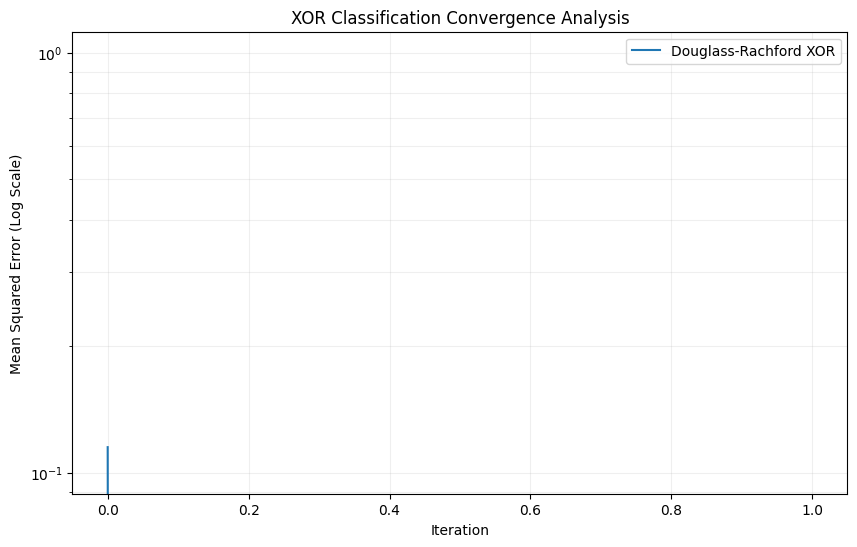

In [83]:
### Visualize Results
import numpy as np
df_results = pd.DataFrame(results.copy())
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x="Iteration", y="Error", label='Douglass-Rachford XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## nonlinear relaxed projection
